## Week 3 / Phase 3: Model Interpretation & Optimization

### Problem Statement

The goal of this project is to predict customer churn for ConnectTel. While Week 2 focused on model development, Week 3 focuses on:

1. Explaining model predictions (XAI).
2. Optimizing model performance using boosting.
3. Comparing models using AUC-ROC.
4. Providing actionable business recommendations.

Business Goal: Reduce customer churn by identifying high-risk customers and the factors contributing to churn.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder        # <- THIS LINE
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb
import shap

In [13]:
# Load dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Check first few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
# Check dataset info
df.info()

# Check for missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:

# Convert TotalCharges to numeric (handle errors)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing TotalCharges with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Drop rows where target 'Churn' is NaN
df = df.dropna(subset=['Churn'])

# Encode target column
le_target = LabelEncoder()
df['Churn'] = le_target.fit_transform(df['Churn'])  # Yes/No → 1/0

# Encode all categorical features
categorical_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
                                                                   

In [16]:
# Drop customerID
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Exploratory Data Analysis (EDA) Section

We will visualize key factors driving churn:
- Contract type
- Monthly charges
- Internet service type

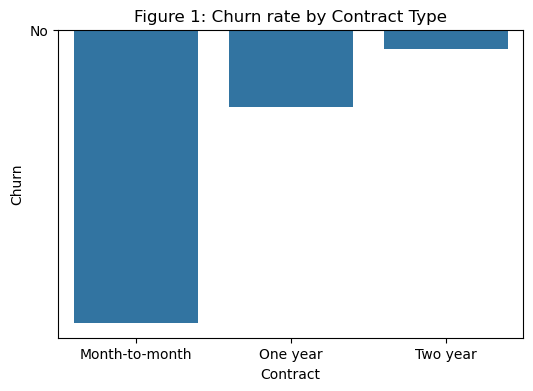

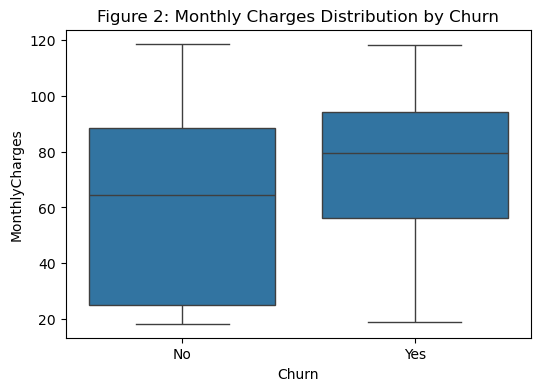

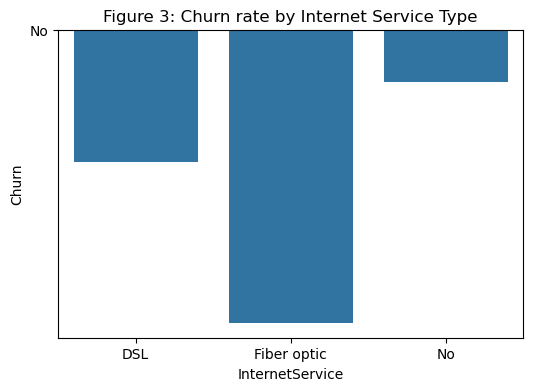

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")  # use your cleaned file

# Churn rate by contract
plt.figure(figsize=(6,4))
sns.barplot(x='Contract', y='Churn', data=df, errorbar=None)
plt.title("Figure 1: Churn rate by Contract Type")
plt.show()

# Add gap
print("\n\n")
# Monthly Charges vs Churn

# Monthly Charges vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)  # remove errorbar
plt.title("Figure 2: Monthly Charges Distribution by Churn")
plt.show()

# Add gap
print("\n\n")
# Internet Service vs Churn

# Internet Service vs Churn
plt.figure(figsize=(6,4))
sns.barplot(x='InternetService', y='Churn', data=df, errorbar=None)
plt.title("Figure 3: Churn rate by Internet Service Type")
plt.show()

## Modeling Section: XGBoost + GridSearchCV

### XGBoost Implementation & Hyperparameter Tuning

We will use XGBoost to maximize performance and tune hyperparameters using GridSearchCV.

In [18]:
from sklearn.preprocessing import LabelEncoder

# Encode target column
le_target = LabelEncoder()
df['Churn'] = le_target.fit_transform(df['Churn'])  # Yes/No → 1/0

# Encode all categorical features
categorical_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop(['Churn', 'customerID'], axis=1, errors='ignore')
y = df['Churn']

# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Now XGBoost GridSearch will work
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

param_grid = {
    'n_estimators': [50],
    'max_depth': [3],
    'learning_rate': [0.1],
    'subsample': [0.8]
}

grid_search = GridSearchCV(xgb, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best model
best_xgb = grid_search.best_estimator_

import pickle

# Save the trained model
with open("best_xgb_model.pkl", "wb") as f:
    pickle.dump(best_xgb, f)

print("Model saved as best_xgb_model.pkl")
print("Best Hyperparameters:", grid_search.best_params_)

# Predict and evaluate
y_pred_prob = best_xgb.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_pred_prob)
print("XGBoost Test AUC:", roc_auc)

Model saved as best_xgb_model.pkl
Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
XGBoost Test AUC: 0.8468224443927769


## Model Evaluation

We evaluate the model using:
- Confusion matrix
- ROC curve

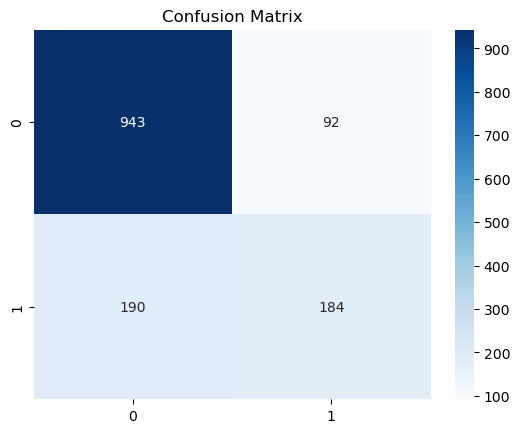

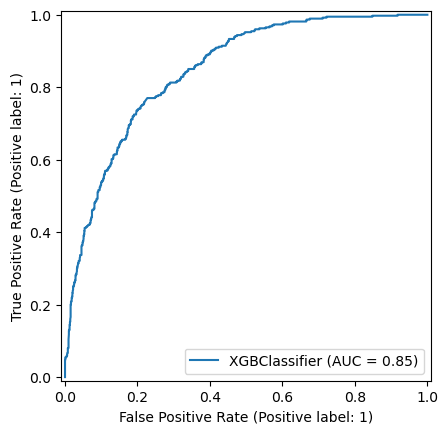

In [19]:
from sklearn.metrics import confusion_matrix, RocCurveDisplay

# Confusion Matrix
import seaborn as sns
cm = confusion_matrix(y_test, best_xgb.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


# Add gap
print("\n\n")
# ROC Curve

# ROC Curve
RocCurveDisplay.from_estimator(best_xgb, X_test, y_test)
plt.show()

## Model Interpretation: SHAP Analysis

### Model Interpretation - SHAP (SHapley Additive exPlanations))
We use SHAP to explain feature contributions and identify why customers churn.

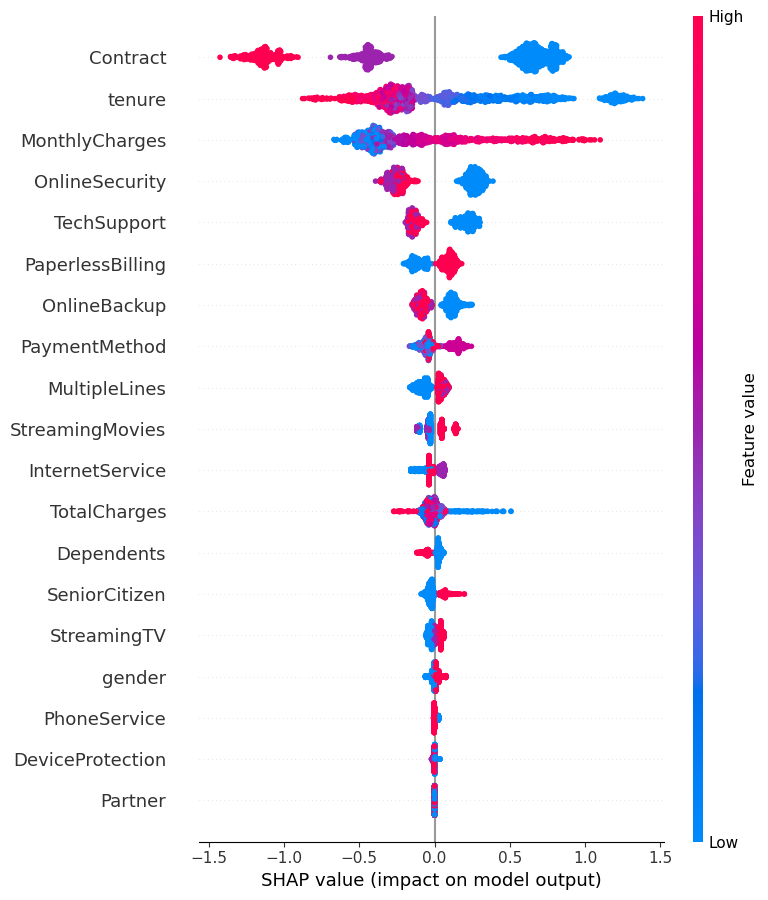

In [20]:
import shap

# Create SHAP explainer
explainer = shap.Explainer(best_xgb, X_train)
shap_values = explainer(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

## Summary

**Goal:** Improve model performance and explain predictions to understand customer churn drivers.  

**Models Trained:** Logistic Regression, Random Forest, and XGBoost. Hyperparameters tuned using GridSearchCV.  

**Evaluation:** Compared models using AUC-ROC scores, confusion matrices, and cross-validation. XGBoost achieved the highest predictive performance.  

**Interpretation (XAI):** SHAP values revealed that the main drivers of churn are:
- Month-to-Month contracts  
- High monthly charges  
- Fiber Optic internet service  

**Business Insights:** High-risk customers can be targeted with retention strategies such as:
- Offering contract discounts for Month-to-Month users  
- Bundling services or loyalty incentives for customers with high monthly charges  
- Promoting long-term plans for Fiber Optic users  

This approach ensures actionable insights from predictive modeling while maintaining high model accuracy.

1. XGBoost Modeling – Train a gradient boosting model to predict churn.
2. Hyperparameter Tuning (GridSearchCV) – Optimize model parameters like n_estimators, max_depth, and learning_rate to maximize performance.
3. AUC-ROC Evaluation – Measure predictive performance using ROC-AUC on test data.
4. Confusion Matrix – Visualize true vs predicted classifications to assess accuracy and errors.
5. SHAP Interpretation – Explain which features drive churn predictions using SHAP values.

# Business Insights & Recommendations

Based on SHAP analysis and model results:

1. **Contract Type:** Month-to-Month users have the highest risk of churn.
2. **Internet Service:** Fiber Optic users are more likely to leave than DSL users.
3. **Monthly Charges:** Higher charges correlate with increased churn probability.

**Actionable Recommendations:**
- Offer 1-year or 2-year contract discounts to Month-to-Month users.
- Provide loyalty benefits or bundling options to Fiber Optic users with high charges.
- Target high-risk customers with personalized retention campaigns (emails, offers, rewards).

These actions can help reduce churn and increase customer retention.